In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
dataset=pd.read_csv('/content/drive/MyDrive/Deeplearning/code/Churn_Modelling.csv')

In [ ]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
x=dataset.iloc[:,3:13]
y=dataset['Exited']

In [ ]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
#encoding
geography =pd.get_dummies(x['Geography'],drop_first=True)
gender =pd.get_dummies(x['Gender'],drop_first=True)

In [ ]:
x=x.drop(['Geography','Gender'],axis=1)
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [ ]:
x=pd.concat([x,geography,gender],axis=1)

In [ ]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.33, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
X_train.shape

(6700, 11)

In [ ]:
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau

In [ ]:
# It is a callback that reduces the learning rate (LR) when the model stops improving.
# Only treat a change in the monitored metric as improvement if it is greater than 0.0001

In [ ]:
# 4) Callbacks
early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    verbose=1,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

callbacks = [early_stopping, checkpoint, reduce_lr]


In [ ]:
# 5) Fit
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True,  # It shuffles the training samples before each epoch.
    verbose=2
)

Epoch 1/100

Epoch 1: val_loss improved from inf to 0.40274, saving model to best_model.h5


210/210 - 3s - 14ms/step - accuracy: 0.8072 - loss: 0.4678 - val_accuracy: 0.8285 - val_loss: 0.4027 - learning_rate: 1.0000e-03
Epoch 2/100

Epoch 2: val_loss improved from 0.40274 to 0.38079, saving model to best_model.h5


210/210 - 1s - 4ms/step - accuracy: 0.8209 - loss: 0.4259 - val_accuracy: 0.8455 - val_loss: 0.3808 - learning_rate: 1.0000e-03
Epoch 3/100

Epoch 3: val_loss improved from 0.38079 to 0.35829, saving model to best_model.h5


210/210 - 1s - 3ms/step - accuracy: 0.8369 - loss: 0.4031 - val_accuracy: 0.8576 - val_loss: 0.3583 - learning_rate: 1.0000e-03
Epoch 4/100

Epoch 4: val_loss improved from 0.35829 to 0.34402, saving model to best_model.h5


210/210 - 1s - 6ms/step - accuracy: 0.8434 - loss: 0.3829 - val_accuracy: 0.8661 - val_loss: 0.3440 - learning_rate: 1.0000e-03
Epoch 5/100

Epoch 5: val_loss improved from 0.34402 to 0.33739, saving model to best_model.h5


...

210/210 - 1s - 3ms/step - accuracy: 0.8537 - loss: 0.3560 - val_accuracy: 0.8745 - val_loss: 0.3286 - learning_rate: 1.0000e-03
Epoch 10/100

Epoch 10: val_loss did not improve from 0.32856
210/210 - 1s - 3ms/step - accuracy: 0.8533 - loss: 0.3467 - val_accuracy: 0.8739 - val_loss: 0.3290 - learning_rate: 1.0000e-03
Epoch 11/100

Epoch 11: val_loss did not improve from 0.32856
210/210 - 1s - 3ms/step - accuracy: 0.8549 - loss: 0.3509 - val_accuracy: 0.8776 - val_loss: 0.3306 - learning_rate: 1.0000e-03
Epoch 12/100

Epoch 12: val_loss improved from 0.32856 to 0.32814, saving model to best_model.h5


210/210 - 1s - 3ms/step - accuracy: 0.8567 - loss: 0.3491 - val_accuracy: 0.8770 - val_loss: 0.3281 - learning_rate: 1.0000e-03
Epoch 13/100

Epoch 13: val_loss improved from 0.32814 to 0.32677, saving model to best_model.h5


210/210 - 1s - 3ms/step - accuracy: 0.8588 - loss: 0.3438 - val_accuracy: 0.8752 - val_loss: 0.3268 - learning_rate: 1.0000e-03
Epoch 14/100

Epoch 14: val_loss did not improve from 0.32677
210/210 - 1s - 4ms/step - accuracy: 0.8566 - loss: 0.3490 - val_accuracy: 0.8770 - val_loss: 0.3299 - learning_rate: 1.0000e-03
Epoch 15/100

Epoch 15: val_loss did not improve from 0.32677
210/210 - 1s - 6ms/step - accuracy: 0.8557 - loss: 0.3425 - val_accuracy: 0.8794 - val_loss: 0.3277 - learning_rate: 1.0000e-03
Epoch 16/100

Epoch 16: val_loss did not improve from 0.32677
210/210 - 1s - 4ms/step - accuracy: 0.8587 - loss: 0.3422 - val_accuracy: 0.8739 - val_loss: 0.3275 - learning_rate: 1.0000e-03
Epoch 17/100

Epoch 17: val_loss did not improve from 0.32677
210/210 - 1s - 4ms/step - accuracy: 0.8570 - loss: 0.3407 - val_accuracy: 0.8758 - val_loss: 0.3286 - learning_rate: 1.0000e-03
Epoch 18/100

Epoch 18: val_loss did not improve from 0.32677

Epoch 18: ReduceLROnPlateau reducing learning rat

210/210 - 1s - 3ms/step - accuracy: 0.8643 - loss: 0.3375 - val_accuracy: 0.8733 - val_loss: 0.3264 - learning_rate: 5.0000e-04
Epoch 20/100

Epoch 20: val_loss did not improve from 0.32638
210/210 - 1s - 3ms/step - accuracy: 0.8619 - loss: 0.3354 - val_accuracy: 0.8745 - val_loss: 0.3269 - learning_rate: 5.0000e-04
Epoch 21/100

Epoch 21: val_loss did not improve from 0.32638
210/210 - 1s - 3ms/step - accuracy: 0.8609 - loss: 0.3367 - val_accuracy: 0.8721 - val_loss: 0.3277 - learning_rate: 5.0000e-04
Epoch 22/100

Epoch 22: val_loss improved from 0.32638 to 0.32561, saving model to best_model.h5


210/210 - 1s - 3ms/step - accuracy: 0.8619 - loss: 0.3330 - val_accuracy: 0.8752 - val_loss: 0.3256 - learning_rate: 5.0000e-04
Epoch 23/100

Epoch 23: val_loss did not improve from 0.32561
210/210 - 1s - 3ms/step - accuracy: 0.8625 - loss: 0.3343 - val_accuracy: 0.8727 - val_loss: 0.3265 - learning_rate: 5.0000e-04
Epoch 24/100

Epoch 24: val_loss did not improve from 0.32561
210/210 - 1s - 3ms/step - accuracy: 0.8619 - loss: 0.3326 - val_accuracy: 0.8727 - val_loss: 0.3277 - learning_rate: 5.0000e-04
Epoch 25/100

Epoch 25: val_loss did not improve from 0.32561
210/210 - 1s - 3ms/step - accuracy: 0.8603 - loss: 0.3332 - val_accuracy: 0.8727 - val_loss: 0.3265 - learning_rate: 5.0000e-04
Epoch 26/100

Epoch 26: val_loss did not improve from 0.32561
210/210 - 1s - 3ms/step - accuracy: 0.8609 - loss: 0.3340 - val_accuracy: 0.8727 - val_loss: 0.3264 - learning_rate: 5.0000e-04
Epoch 27/100

Epoch 27: val_loss did not improve from 0.32561

Epoch 27: ReduceLROnPlateau reducing learning rat

In [ ]:
# 6) Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss, "Test acc:", test_acc)

Test loss: 0.3375236392021179 Test acc: 0.8557575941085815


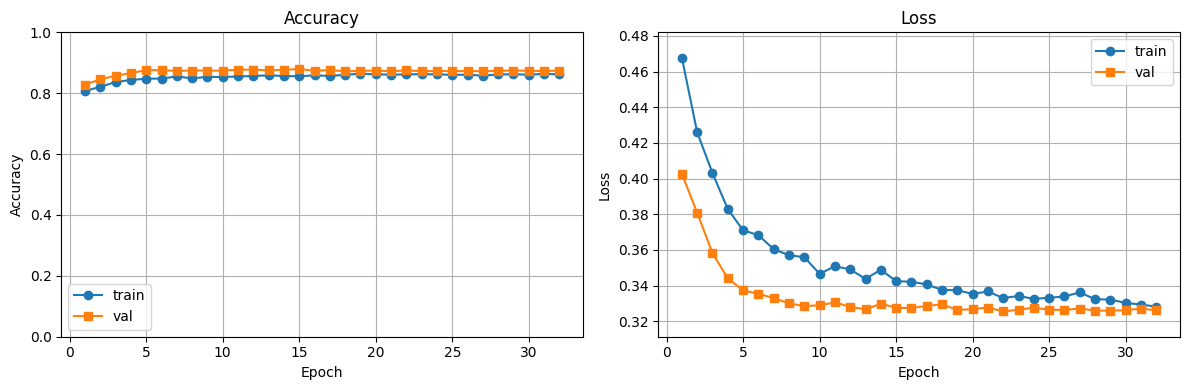

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, acc, marker='o', label='train')
plt.plot(epochs, val_acc, marker='s', label='val')
plt.title('Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.ylim(0.0, 1.0)

plt.subplot(1,2,2)
plt.plot(epochs, loss, marker='o', label='train')
plt.plot(epochs, val_loss, marker='s', label='val')
plt.title('Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
miny = min(min(loss), min(val_loss)); maxy = max(max(loss), max(val_loss))
pad = max((maxy-miny)*0.1, 1e-6)
plt.ylim(max(0, miny-pad), maxy+pad)

plt.tight_layout(); plt.show()